In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df1 = pd.read_csv('recording1.csv')
display(df1.head(3))

,timestamp_ms,orp_mV
0,1984,-35
1,2224,-35
2,2462,-36


In [4]:
df2 = pd.read_csv('recording2.csv')
df3 = pd.read_csv('recording3.csv')

df1['run']= 'recording1'
df2['run']= 'recording2'
df3['run']= 'recording3'

combined_df = pd.concat([df1, df2, df3], ignore_index = True)
combined_df['time_s'] = combined_df['timestamp_ms']/1000.0


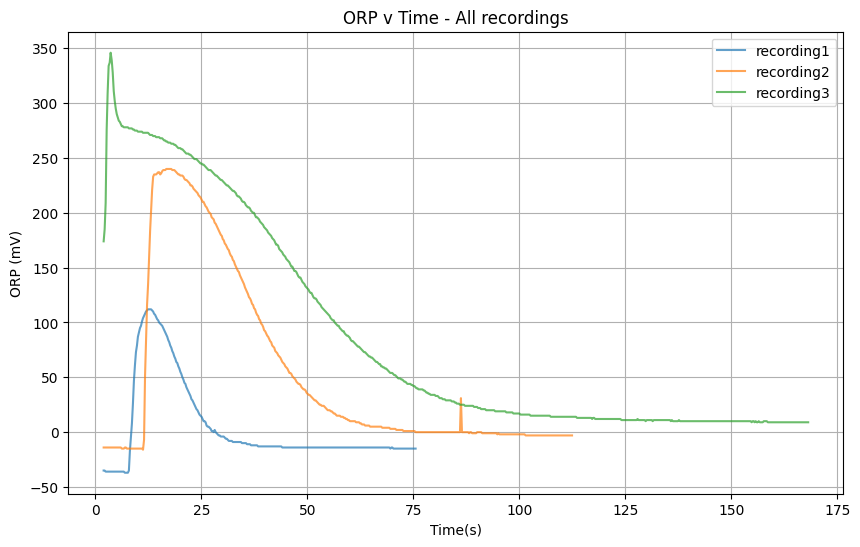

In [5]:
plt.figure(figsize=(10,6))

for name, group in combined_df.groupby('run'):
    plt.plot(group['time_s'], group['orp_mV'], label=name, alpha=0.7)

plt.xlabel('Time(s)')
plt.ylabel('ORP (mV)')
plt.title('ORP v Time - All recordings')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
combined_df = combined_df.set_index(pd.to_timedelta(combined_df['timestamp_ms'], unit='ms'))
Hz = 4
min_pts = int(Hz*3)
combined_df['rolling_mean'] = combined_df.groupby('run')['orp_mV'].transform(lambda x: x.rolling('5s').mean())
combined_df['rolling_std']= combined_df.groupby('run')['orp_mV'].transform(lambda x: x.rolling('5s', min_periods=min_pts).std())

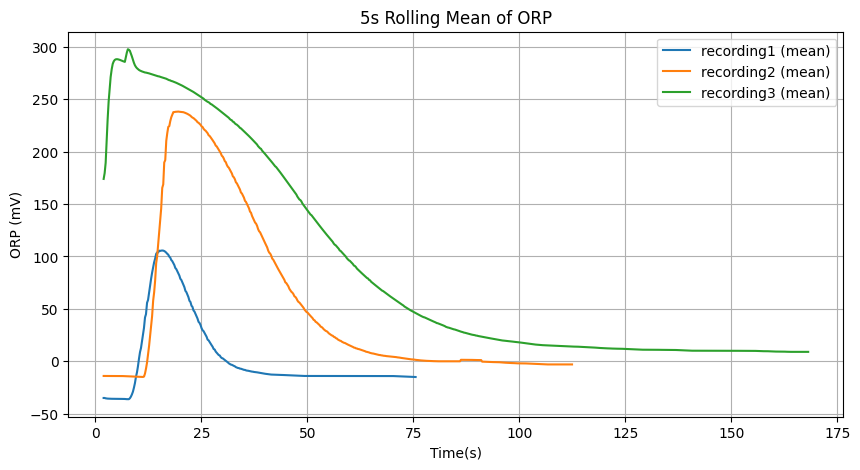

In [7]:
plt.figure(figsize=(10,5))
for name,group in combined_df.groupby('run'):
    plt.plot(group['time_s'], group['rolling_mean'], label=f'{name} (mean)')
    plt.xlabel ('Time(s)')
    plt.ylabel('ORP (mV)')
    plt.title('5s Rolling Mean of ORP')
    plt.legend()
    plt.grid(True)
plt.show()

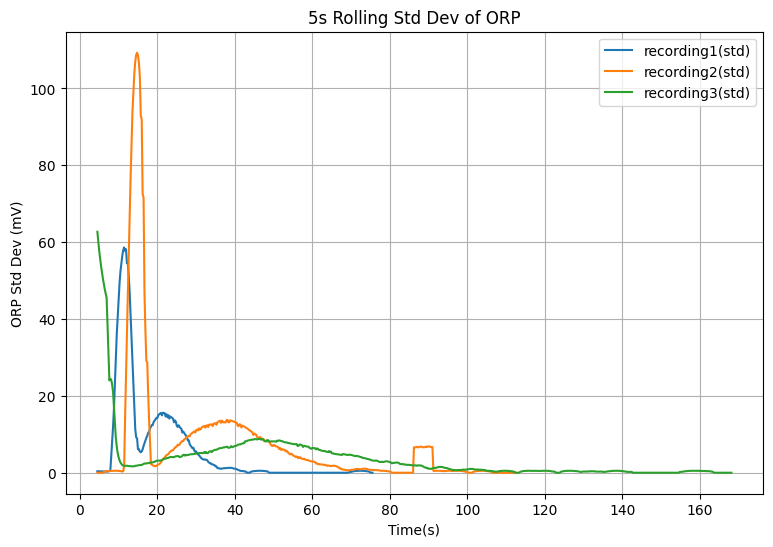

In [20]:
plt.figure(figsize=(9,6))
for name,group in combined_df.groupby('run'):
    plt.plot(group['time_s'],group['rolling_std'],label=f'{name}(std)')
    plt.xlabel('Time(s)')
    plt.ylabel('ORP Std Dev (mV)')
    plt.title('5s Rolling Std Dev of ORP')
    plt.legend()
    plt.grid(True)

In [35]:

combined_df["t"] = pd.to_timedelta(combined_df["timestamp_ms"], unit="ms")
combined_df = combined_df.set_index("t").sort_index()
combined_df.index.name = "t"   

stable_threshold = 5.0
duration_req = "10s"

for name, g in combined_df.groupby("run", sort=False):
    
    below  = (g["rolling_std"] < stable_threshold)
    stayed = below.rolling(duration_req).apply(lambda w: 1.0 if w.all() else 0.0)
    idx = stayed[stayed == 1.0].index.min()
    if pd.notna(idx):
        t0 = pd.to_timedelta(g["timestamp_ms"].iloc[0], unit="ms")
        t_stable = (idx - t0).total_seconds()
        print(f"{name} stabilized after {t_stable:.1f} s")
    else:
        print(f"{name} never met stability criterion")



recording1 stabilized after 38.6 s
recording3 stabilized after 17.8 s
recording2 stabilized after 62.1 s
